<a href="https://colab.research.google.com/github/shafiqa-nabila/PCVK_Ganjil2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 30


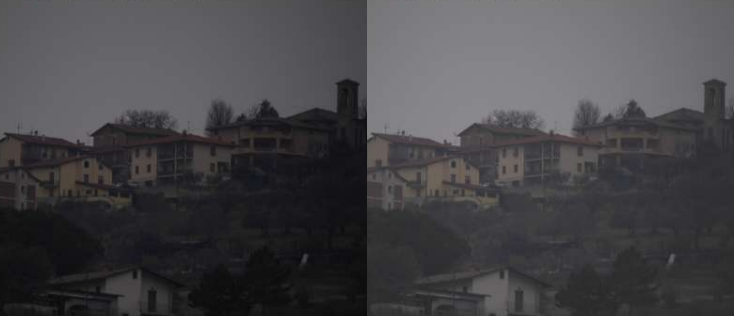

In [ ]:
print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')

try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')
    brightness = 30

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y, x, c] = np.clip(original[y, x, c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

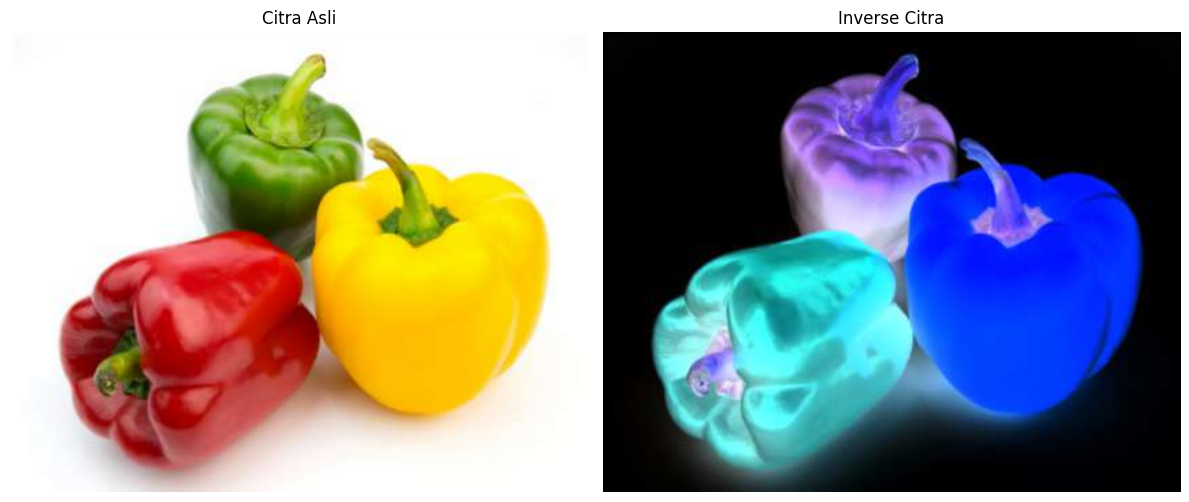

In [ ]:
original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/peppers.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

inverse = 255 - original_rgb

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(inverse)
plt.title('Inverse Citra')
plt.axis('off')

plt.tight_layout()
plt.show()

Mengubah kontras dan tingkat kecerahan citra
----------------------------------------------
Masukkan tingkat kecerahan : 10
Masukkan kontras : 1.5


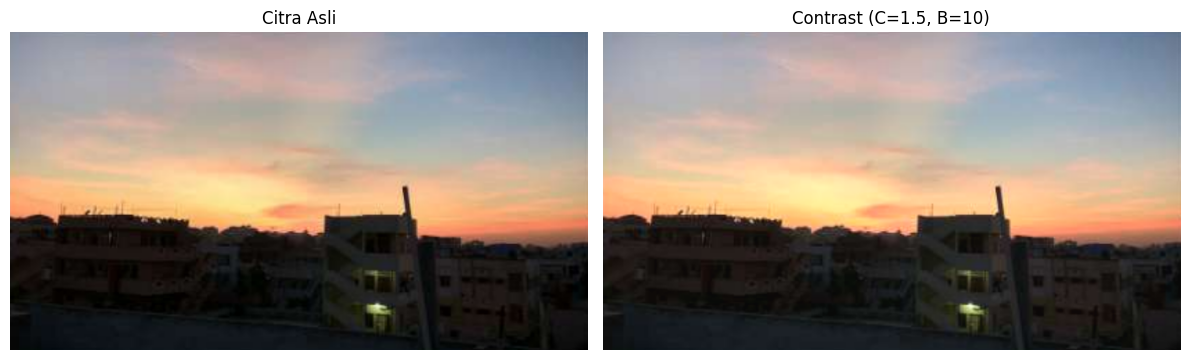

In [ ]:
print('Mengubah kontras dan tingkat kecerahan citra')
print('----------------------------------------------')

try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    print('Error, not a number')
    brightness = 10
    contrast = 1.5

original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/images.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

factor = (259 * (contrast + 255)) / (255 * (259 - contrast))

contrast_image = np.zeros(original_rgb.shape, original_rgb.dtype)

for y in range(original_rgb.shape[0]):
    for x in range(original_rgb.shape[1]):
        for c in range(original_rgb.shape[2]):
            nilai = factor * (int(original_rgb[y, x, c]) - 128) + 128 + brightness
            contrast_image[y, x, c] = np.clip(nilai, 0, 255)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(contrast_image)
plt.title(f'Contrast (C={contrast}, B={brightness})')
plt.axis('off')

plt.tight_layout()
plt.show()


Mengubah tingkat kecerahan citra dengan Transformasi Log
---------------------------------------------------------
Masukkan nilai kecerahan: 50


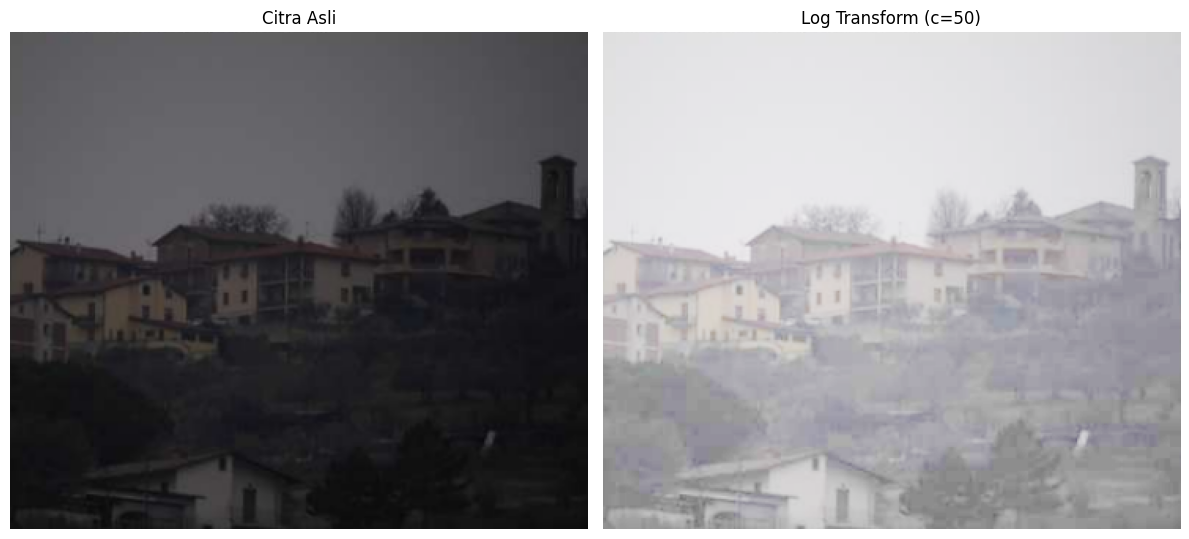

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('---------------------------------------------------------')

try:
    c = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    c = 50

# Baca gambar houses.jpg
original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/houses.jpg')

# Konversi ke float untuk perhitungan log
original_float = original.astype(np.float32)

# Transformasi log: s = c * log(1 + r)
log_image = c * np.log(1 + original_float)

# Clip ke 0-255
log_image = np.clip(log_image, 0, 255).astype(np.uint8)

# Tampilkan
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(log_image, cv.COLOR_BGR2RGB))
plt.title(f'Log Transform (c={c})')
plt.axis('off')

plt.tight_layout()
plt.show()

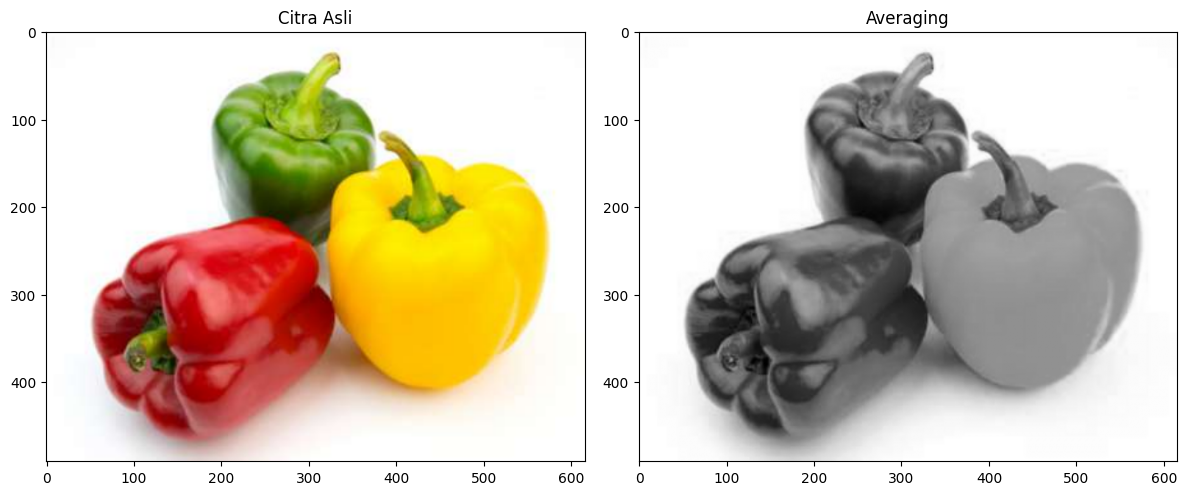

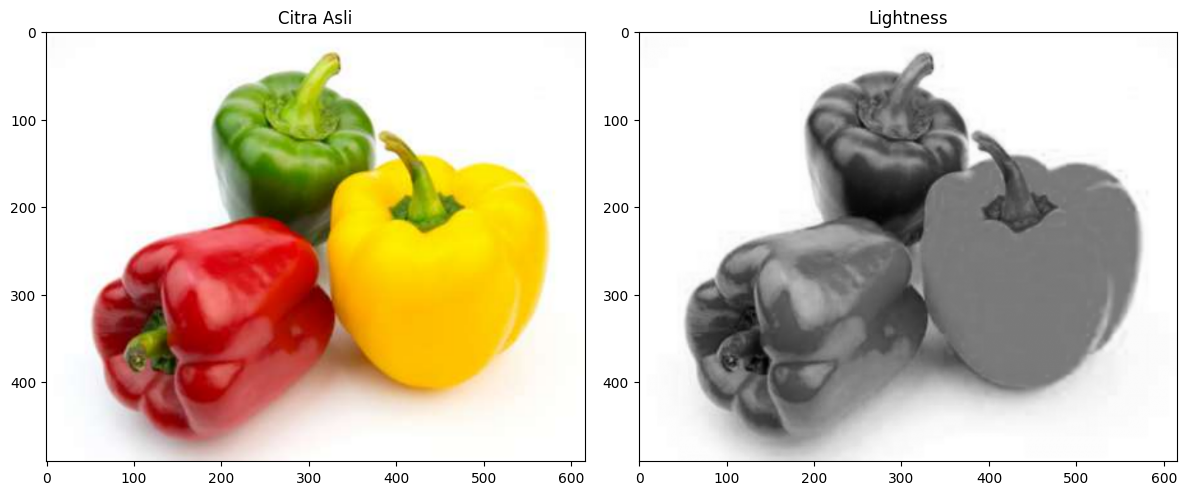

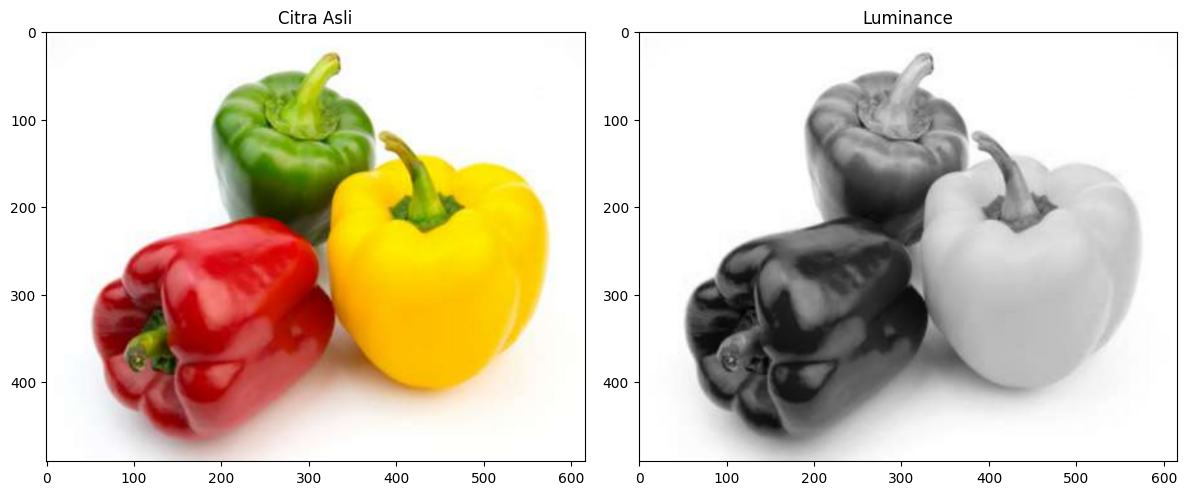

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/peppers.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

h, w, c = original_rgb.shape

# Siapkan kanvas grayscale
gray_avg = np.zeros((h, w), np.uint8)
gray_light = np.zeros((h, w), np.uint8)
gray_lum = np.zeros((h, w), np.uint8)

# Loop tiap pixel
for y in range(h):
    for x in range(w):
        R = int(original_rgb[y, x, 0])
        G = int(original_rgb[y, x, 1])
        B = int(original_rgb[y, x, 2])

        # Averaging
        gray_avg[y, x] = (R + G + B) // 3

        # Lightness
        gray_light[y, x] = (max(R, G, B) + min(R, G, B)) // 2

        # Luminance
        gray_lum[y, x] = int(0.21 * R + 0.72 * G + 0.07 * B)

# ============================================
# TAMPILKAN - a. Averaging
# ============================================

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Citra Asli')

plt.subplot(1, 2, 2)
plt.imshow(gray_avg, cmap='gray')
plt.title('Averaging')

plt.tight_layout()
plt.show()

# ============================================
# TAMPILKAN - b. Lightness
# ============================================

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Citra Asli')

plt.subplot(1, 2, 2)
plt.imshow(gray_light, cmap='gray')
plt.title('Lightness')

plt.tight_layout()
plt.show()

# ============================================
# TAMPILKAN - c. Luminance
# ============================================

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Citra Asli')

plt.subplot(1, 2, 2)
plt.imshow(gray_lum, cmap='gray')
plt.title('Luminance')

plt.tight_layout()
plt.show()

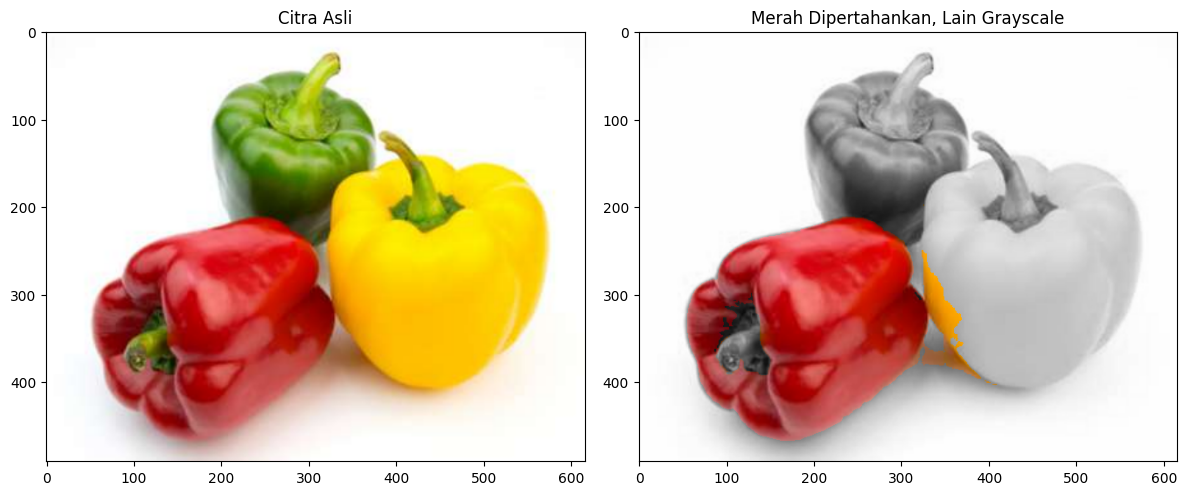

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/peppers.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

h, w, c = original_rgb.shape

hasil = np.zeros((h, w, 3), np.uint8)

for y in range(h):
    for x in range(w):
        R = int(original_rgb[y, x, 0])
        G = int(original_rgb[y, x, 1])
        B = int(original_rgb[y, x, 2])

        if R > 100 and R > G * 1.5 and R > B * 1.5:
            hasil[y, x] = original_rgb[y, x]
        else:
            gray = int(0.21 * R + 0.72 * G + 0.07 * B)
            hasil[y, x] = [gray, gray, gray]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Citra Asli')

plt.subplot(1, 2, 2)
plt.imshow(hasil)
plt.title('Merah Dipertahankan, Lain Grayscale')

plt.tight_layout()
plt.show()

 Gamma Correction pada citra 
------------------------------
Masukkan nilai Gamma: 0.5


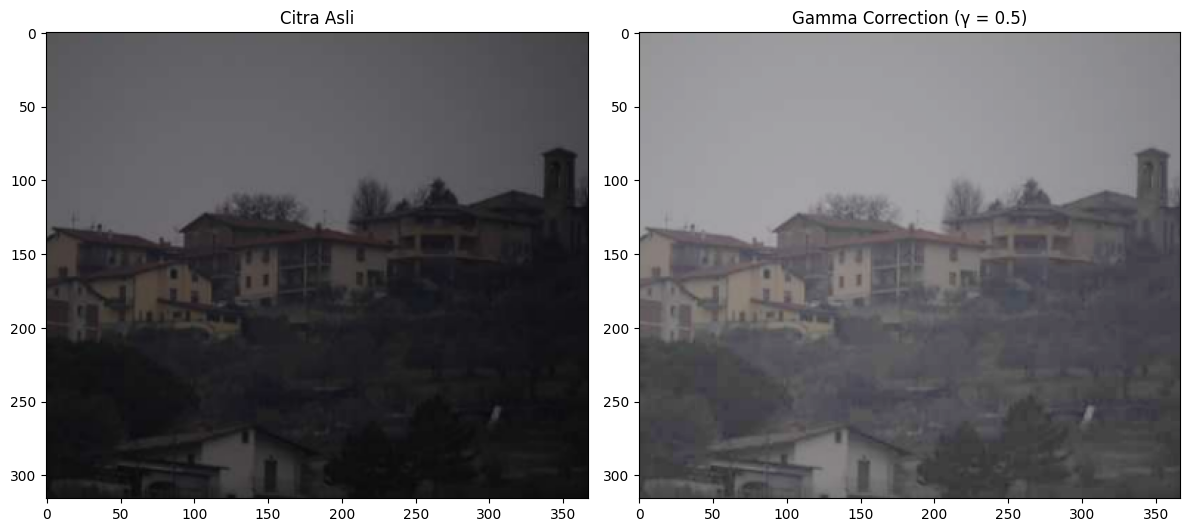

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print(' Gamma Correction pada citra ')
print('------------------------------')

try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')
    gamma = 0.5

original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/houses.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

original_float = original_rgb.astype(np.float32) / 255.0

gamma_image = 255 * np.power(original_float, gamma)
gamma_image = np.clip(gamma_image, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Citra Asli')

plt.subplot(1, 2, 2)
plt.imshow(gamma_image)
plt.title(f'Gamma Correction (γ = {gamma})')

plt.tight_layout()
plt.show()


Masukkan bit depth tujuan (1-8): 3
Bit depth awal  : 8 bit
Bit depth tujuan: 3 bit
Jumlah level    : 8


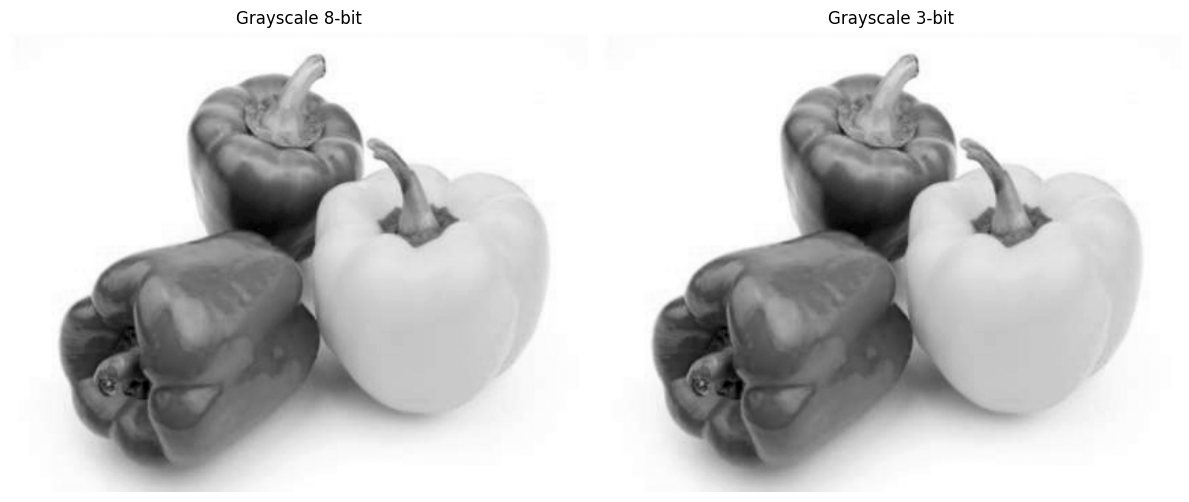

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Input bit depth
try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
except ValueError:
    bit_depth = 3

print(f'Bit depth awal  : 8 bit')
print(f'Bit depth tujuan: {bit_depth} bit')

# Hitung level
level = 255 / (pow(2, bit_depth) - 1)
print(f'Jumlah level    : {int(pow(2, bit_depth))}')

# Baca gambar grayscale
original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/peppers.jpg', cv.IMREAD_GRAYSCALE)
depth_image = np.zeros(original.shape, original.dtype)

# Loop tiap pixel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        C = int(original[y, x])
        C_new = round((C / level) * level)
        depth_image[y, x] = np.clip(C_new, 0, 255)

# Tampilkan
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap='gray')
plt.title('Grayscale 8-bit')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(depth_image, cmap='gray')
plt.title(f'Grayscale {bit_depth}-bit')
plt.axis('off')

plt.tight_layout()
plt.show()


Total citra noise: 100
Average 10 citra -> PSNR: 28.83 dB
Average 20 citra -> PSNR: 28.95 dB
Average 40 citra -> PSNR: 28.93 dB
Average 80 citra -> PSNR: 28.92 dB
Average 100 citra -> PSNR: 28.92 dB

=== TABEL HASIL PSNR ===
No | Jumlah Citra | PSNR (dB)
---|--------------|----------
1  |           10 | 28.83
2  |           20 | 28.95
3  |           40 | 28.93
4  |           80 | 28.92
5  |          100 | 28.92


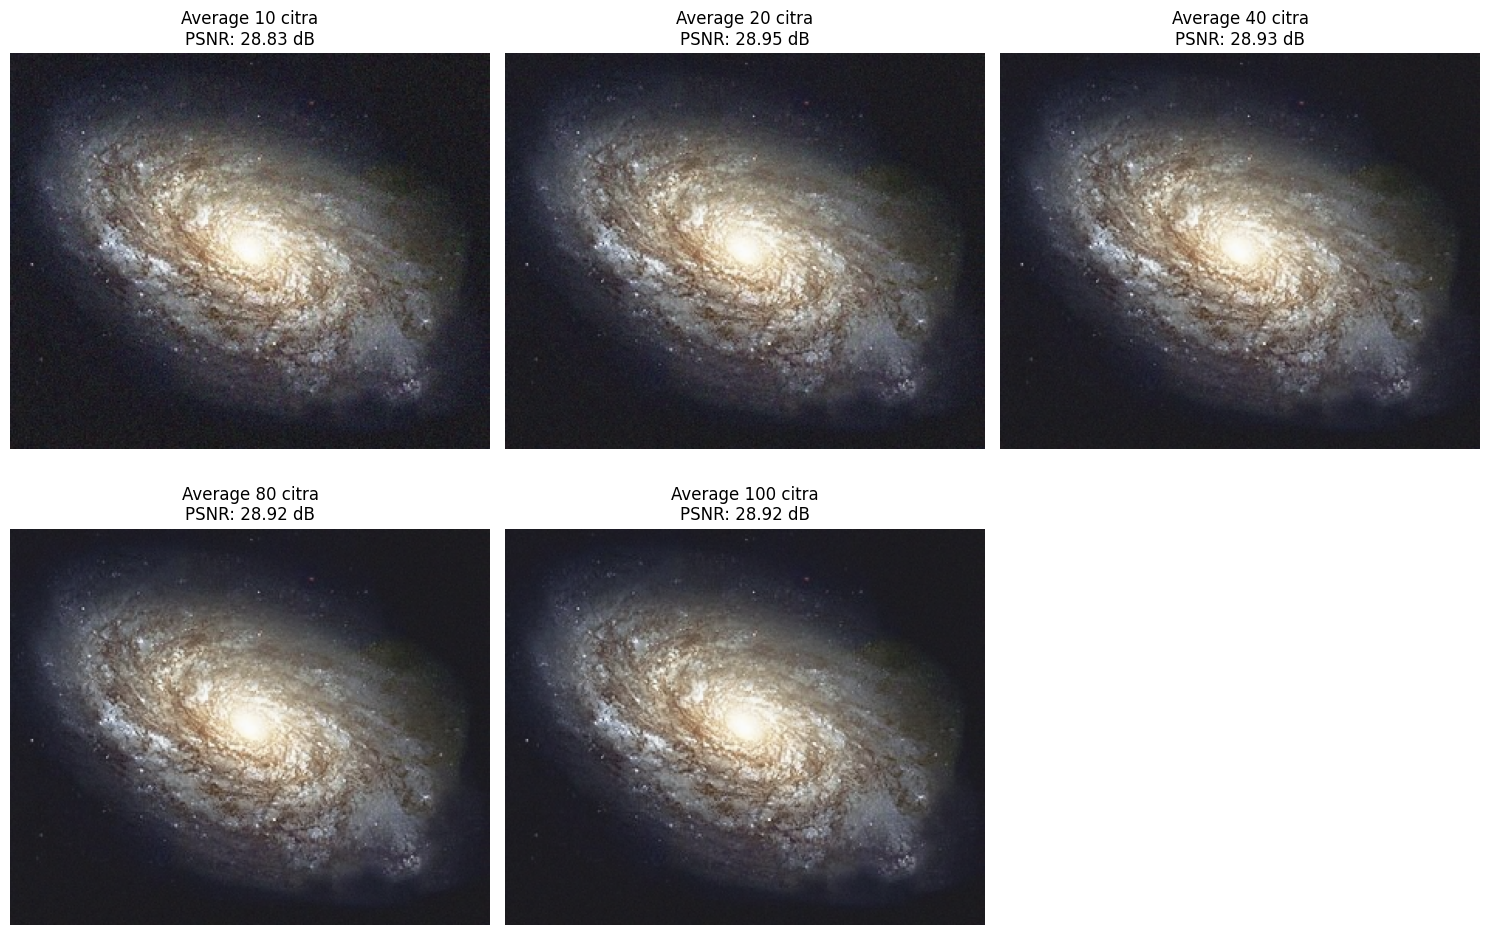

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
from math import log10, sqrt

def PSNR(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr

# Baca citra asli (galaxy.jpg)
original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/galaxy.jpg')

# Baca semua citra noise
cv_img = []
for img in glob.glob('/content/drive/MyDrive/PCVK 2026/Images/noises/*.jpg'):
    n = cv.imread(img)
    cv_img.append(n)

print(f'Total citra noise: {len(cv_img)}')

# Uji average denoising
jumlah_list = [10, 20, 40, 80, 100]
hasil_psnr = []
hasil_image = []

for jumlah in jumlah_list:
    # Average
    avg = np.zeros(cv_img[0].shape, np.float64)
    for i in range(jumlah):
        avg += cv_img[i].astype(np.float64)
    avg = (avg / jumlah).astype(np.uint8)
    hasil_image.append(avg)

    # Hitung PSNR
    psnr = PSNR(original, avg)
    hasil_psnr.append(psnr)
    print(f'Average {jumlah} citra -> PSNR: {psnr:.2f} dB')

# ============================================
# TABEL HASIL
# ============================================

print('\n=== TABEL HASIL PSNR ===')
print('No | Jumlah Citra | PSNR (dB)')
print('---|--------------|----------')
for i, (jml, psnr) in enumerate(zip(jumlah_list, hasil_psnr), 1):
    print(f'{i}  | {jml:12d} | {psnr:.2f}')

# ============================================
# TAMPILKAN GAMBAR
# ============================================

plt.figure(figsize=(15, 10))

for i, (jml, img) in enumerate(zip(jumlah_list, hasil_image)):
    plt.subplot(2, 3, i+1)
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(f'Average {jml} citra\nPSNR: {hasil_psnr[i]:.2f} dB')
    plt.axis('off')

plt.tight_layout()
plt.show()

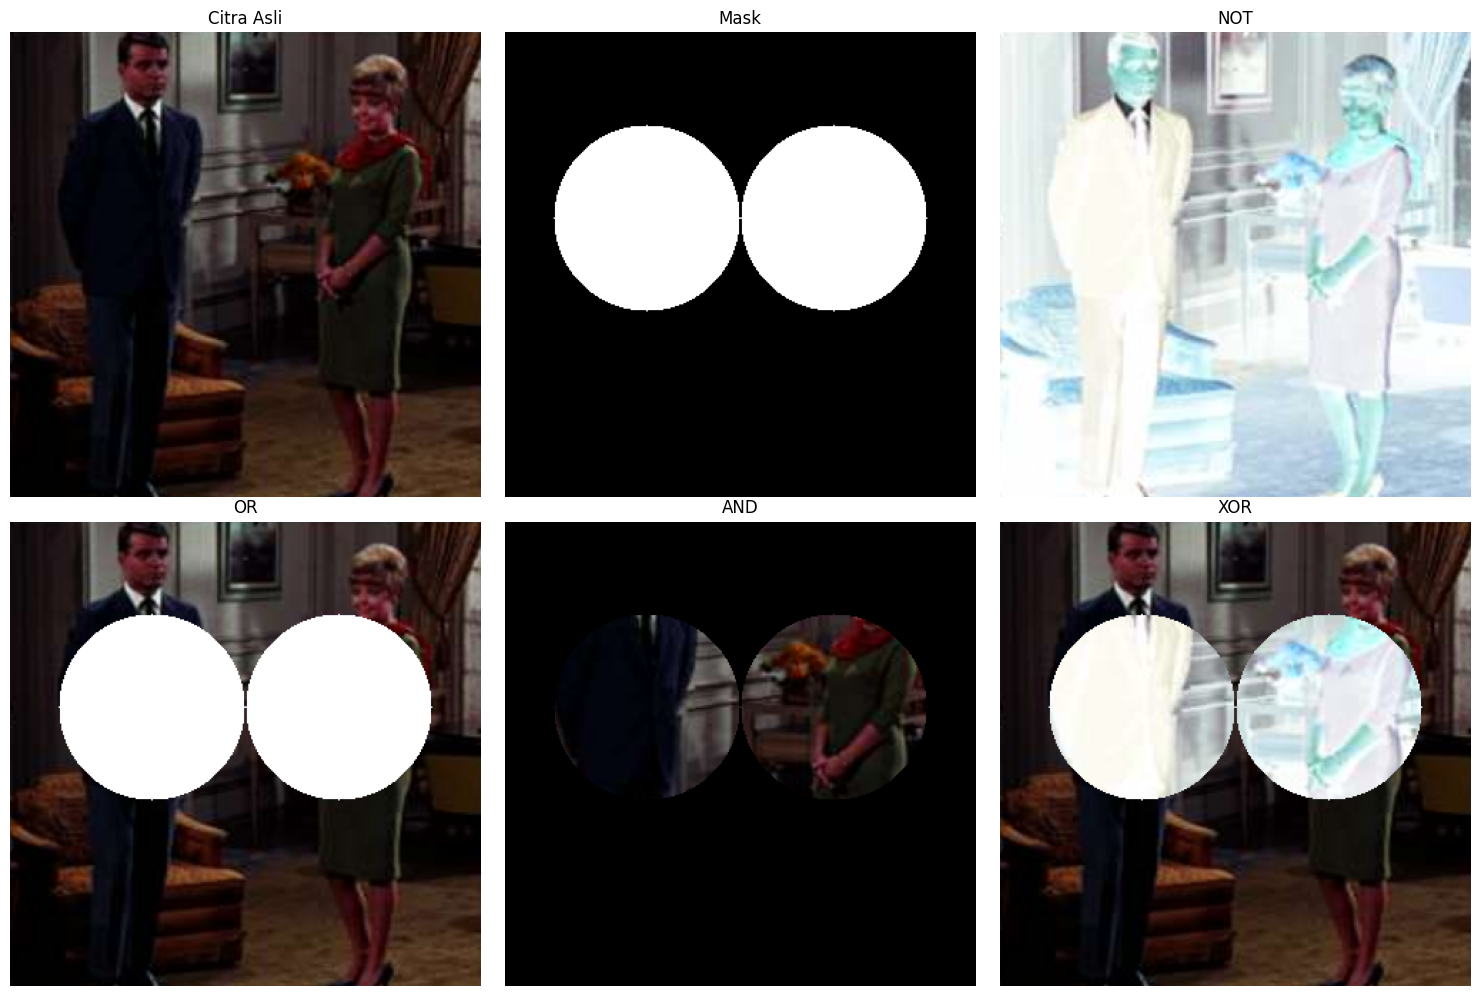

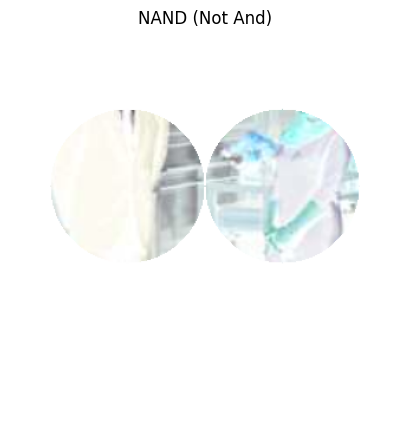

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/couple.tiff')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

h, w = original_rgb.shape[:2]

# Buat mask (2 lingkaran putih)
mask = np.zeros((h, w, 3), np.uint8)
cv.circle(mask, (int(w*0.3), int(h*0.4)), int(min(w,h)*0.2), (255,255,255), -1)
cv.circle(mask, (int(w*0.7), int(h*0.4)), int(min(w,h)*0.2), (255,255,255), -1)

# ============================================
# OPERATOR LOGIKA
# ============================================

# 1. NOT (komplemen)
hasil_not = cv.bitwise_not(original_rgb)

# 2. OR
hasil_or = cv.bitwise_or(original_rgb, mask)

# 3. AND
hasil_and = cv.bitwise_and(original_rgb, mask)

# 4. NAND (Not And)
hasil_nand = cv.bitwise_not(hasil_and)

# 5. XOR
hasil_xor = cv.bitwise_xor(original_rgb, mask)

# ============================================
# TAMPILKAN SEMUA
# ============================================

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(original_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(mask)
plt.title('Mask')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(hasil_not)
plt.title('NOT')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(hasil_or)
plt.title('OR')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(hasil_and)
plt.title('AND')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(hasil_xor)
plt.title('XOR')
plt.axis('off')

plt.tight_layout()
plt.show()

# NAND ditampilkan terpisah
plt.figure(figsize=(6, 5))
plt.imshow(hasil_nand)
plt.title('NAND (Not And)')
plt.axis('off')
plt.show()

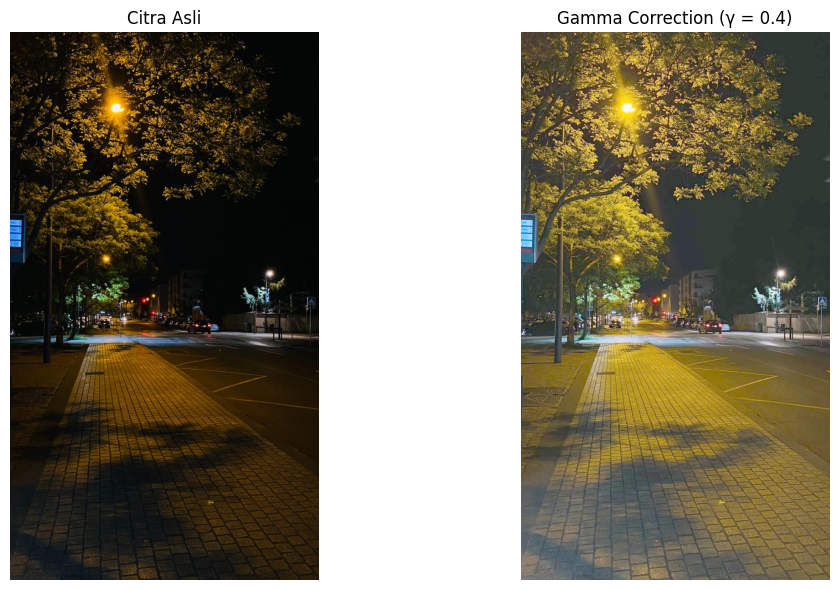

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca foto malam
malam = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/malam.jpg')
malam_rgb = cv.cvtColor(malam, cv.COLOR_BGR2RGB)

# Metode: Gamma Correction
gamma = 0.4
malam_float = malam_rgb.astype(np.float32) / 255.0
malam_cerah = 255 * np.power(malam_float, gamma)
malam_cerah = np.clip(malam_cerah, 0, 255).astype(np.uint8)

# Tampilkan
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(malam_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(malam_cerah)
plt.title(f'Gamma Correction (γ = {gamma})')
plt.axis('off')

plt.tight_layout()
plt.show()

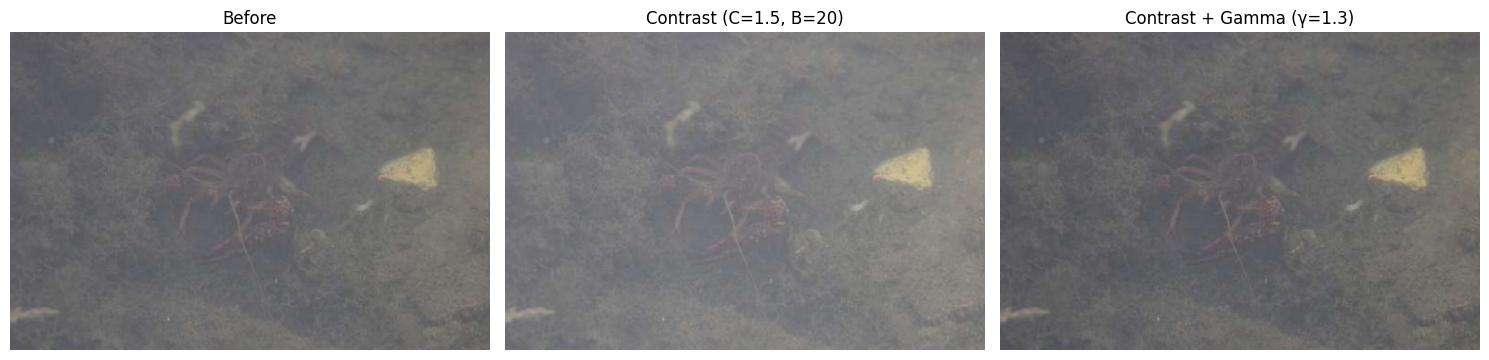

In [ ]:
cray = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/crayfish.jpg')
cray_rgb = cv.cvtColor(cray, cv.COLOR_BGR2RGB)

# Contrast + Brightness
contrast = 1.5
brightness = 20
factor = (259 * (contrast + 255)) / (255 * (259 - contrast))
cray_contrast = np.zeros(cray_rgb.shape, cray_rgb.dtype)

for y in range(cray_rgb.shape[0]):
    for x in range(cray_rgb.shape[1]):
        for c in range(cray_rgb.shape[2]):
            nilai = factor * (int(cray_rgb[y, x, c]) - 128) + 128 + brightness
            cray_contrast[y, x, c] = np.clip(nilai, 0, 255)

# Gamma Correction
gamma = 1.3
cray_float = cray_contrast.astype(np.float32) / 255.0
cray_final = 255 * np.power(cray_float, gamma)
cray_final = np.clip(cray_final, 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cray_rgb)
plt.title('Before')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(cray_contrast)
plt.title(f'Contrast (C={contrast}, B={brightness})')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(cray_final)
plt.title(f'Contrast + Gamma (γ={gamma})')
plt.axis('off')
plt.tight_layout()
plt.show()